# 02 - Feature Engineering para Predicción de Dengue

**Proyecto**: MLOps para Predicción de Dengue en Brasil  
**Autor**: Jose María Ponce Bernabé  
**Fecha**: Septiembre 2025

## Objetivos

1. Crear features que capturen estacionalidad, efectos climáticos retardados y heterogeneidad geográfica
2. Respetar restricciones temporales: solo variables disponibles en tiempo de predicción
3. Validar utilidad de features con modelo baseline antes de consolidar
4. Generar datasets limpios para producción sin target leakage

## Restricciones de Producción

En predicción en tiempo real, el modelo solo dispone de:
- **Temporales**: fecha, semana epidemiológica, mes, año
- **Geográficas**: municipio, estado, población
- **Climáticas con lag**: clima de 4-8 semanas anteriores (ciclo vectorial del Aedes)

Variables epidemiológicas actuales (`nivel_alerta`, `casos`, `Rt`, `transmisión`, etc.) **NO** están disponibles para predecir el futuro. Las variables climáticas del mismo período tampoco, ya que en producción aún no se habrán registrado.

## Pipeline
1. Setup y clasificación de variables
2. Features temporales (estacionalidad)
3. Features climáticas con lag (4-8 semanas)
4. Features geográficas (región y población)
5. Consolidación y resumen
6. Validación con modelo baseline
7. Pipeline final y datasets

## 1. Setup y Clasificación de Variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

project_root = Path.cwd().parent
data_dir = project_root / 'data'
print(f"Proyecto: {project_root}")
print(f"Datos: {data_dir}")

Proyecto: c:\Users\ponce\CIDaeN\tfm-mlops
Datos: c:\Users\ponce\CIDaeN\tfm-mlops\data


In [2]:
# Cargar datasets del EDA
train_df = pd.read_parquet(data_dir / 'processed' / 'dengue_train_2010_2021.parquet')
val_df = pd.read_parquet(data_dir / 'processed' / 'dengue_validation_2022_2023.parquet')
test_df = pd.read_parquet(data_dir / 'processed' / 'dengue_test_2024.parquet')

print(f"Train: {len(train_df):,} registros ({train_df.year.min()}-{train_df.year.max()})")
print(f"Validation: {len(val_df):,} registros ({val_df.year.min()}-{val_df.year.max()})")
print(f"Test: {len(test_df):,} registros ({test_df.year.min()}-{test_df.year.max()})")

# Clasificación estricta de variables
TARGET = 'nivel'

TEMPORAL_VARS = ['data_iniSE', 'SE', 'year', 'month']
GEO_VARS = ['municipio_geocodigo', 'municipio_nome', 'pop', 'uf', 'state_name']
CLIMATE_VARS = ['tempmin', 'tempmed', 'tempmax', 'umidmin', 'umidmed', 'umidmax']

# Variables con leakage (target, epidemiológicas actuales, IDs sin valor)
LEAKAGE_VARS = [
    'casos_est', 'casos_est_min', 'casos_est_max', 'casos',
    'p_rt1', 'p_inc100k', 'Rt', 'receptivo', 'transmissao', 'nivel_inc',
    'casprov', 'casprov_est', 'casprov_est_min', 'casprov_est_max', 'casconf',
    'versao_modelo', 'Localidade_id', 'id', 'notif_accum_year'
]

print(f"\nTarget: {TARGET}")
print(f"Variables producción: {len(TEMPORAL_VARS + GEO_VARS + CLIMATE_VARS)}")
print(f"Variables leakage: {len(LEAKAGE_VARS)}")

# Verificar que todas las columnas están clasificadas
all_classified = set([TARGET] + TEMPORAL_VARS + GEO_VARS + CLIMATE_VARS + LEAKAGE_VARS)
unclassified = [c for c in train_df.columns if c not in all_classified]
if unclassified:
    print(f"⚠️ Sin clasificar: {unclassified}")
else:
    print("Todas las columnas clasificadas correctamente")

Train: 3,482,380 registros (2010-2021)
Validation: 584,013 registros (2022-2023)
Test: 289,640 registros (2024-2024)

Target: nivel
Variables producción: 15
Variables leakage: 19
Todas las columnas clasificadas correctamente


In [3]:
# Baseline: correlaciones de variables numéricas disponibles
baseline_vars = ['pop', 'year', 'month', 'SE',
                 'tempmed', 'umidmed', 'tempmin', 'tempmax', 'umidmin', 'umidmax']

baseline_corrs = {}
for var in baseline_vars:
    if var in train_df.columns:
        corr = train_df[var].corr(train_df[TARGET])
        baseline_corrs[var] = corr

# Ranking por correlación absoluta
ranking = sorted(baseline_corrs.items(), key=lambda x: abs(x[1]), reverse=True)
print("BASELINE - Correlaciones con nivel_alerta:")
print("-" * 45)
for var, corr in ranking:
    bar = "█" * int(abs(corr) * 100)
    print(f"  {var:12s} | {corr:+.3f} | {bar}")

best_baseline = max(abs(v) for v in baseline_corrs.values())
print(f"\nMejor correlación baseline: {best_baseline:.3f}")
print(f"Objetivo: superar {best_baseline:.3f} con FE")

BASELINE - Correlaciones con nivel_alerta:
---------------------------------------------
  month        | -0.160 | ████████████████
  pop          | +0.103 | ██████████
  tempmin      | +0.063 | ██████
  umidmed      | +0.063 | ██████
  umidmin      | +0.052 | █████
  tempmed      | +0.045 | ████
  umidmax      | +0.033 | ███
  tempmax      | +0.026 | ██
  year         | +0.007 | 
  SE           | -0.000 | 

Mejor correlación baseline: 0.160
Objetivo: superar 0.160 con FE


### Análisis del Baseline

Las correlaciones lineales individuales son bajas (<0.16), coherente con el EDA. Esto confirma la necesidad de feature engineering para capturar relaciones no lineales y estacionales.

**Sobre variables climáticas**: En el dataset, las variables climáticas corresponden a la *misma semana* que los datos epidemiológicos. Para predicción futura, solo podremos usar clima con 4-8 semanas de lag (ciclo de incubación del vector). Las columnas climáticas originales se usarán exclusivamente para crear features con lag y se eliminarán del dataset de producción.

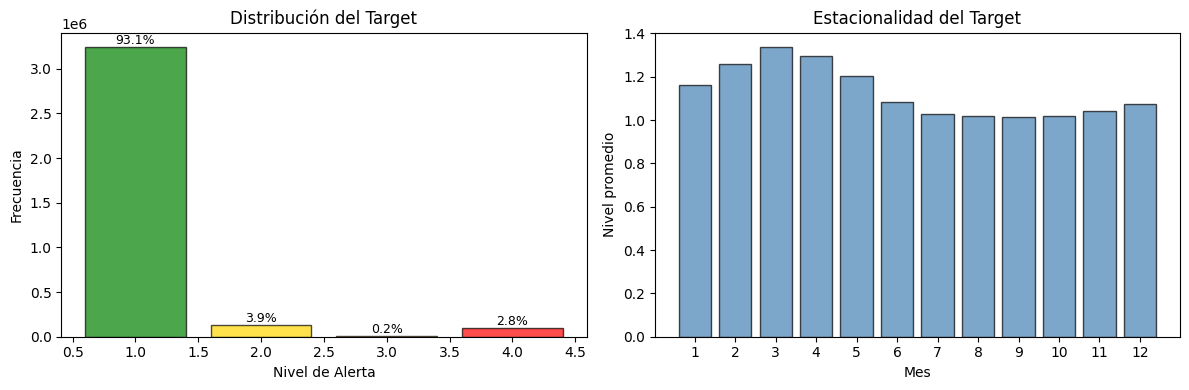

In [4]:
# Visualización del target y estacionalidad
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución del target
nivel_counts = train_df[TARGET].value_counts().sort_index()
colors_alerta = ['green', 'gold', 'orange', 'red']
axes[0].bar(nivel_counts.index, nivel_counts.values, color=colors_alerta, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Nivel de Alerta')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Target')
for idx, val in nivel_counts.items():
    axes[0].text(idx, val, f'{val/len(train_df)*100:.1f}%', ha='center', va='bottom', fontsize=9)

# Estacionalidad
monthly = train_df.groupby('month')[TARGET].mean()
axes[1].bar(monthly.index, monthly.values, alpha=0.7, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Nivel promedio')
axes[1].set_title('Estacionalidad del Target')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

La distribución confirma el desbalance extremo (93.1% nivel 1). Bien visible la estacionalidad.

## 2. Features Temporales

Capturan la fuerte estacionalidad del dengue (pico Mar-Abr, valle Sep) y la referencia de vigilancia por semana epidemiológica. Usamos encoding cíclico para representar la naturaleza circular del tiempo.

In [5]:
# Trabajar sobre copia del train
df = train_df.copy()

# Encoding cíclico de mes (par sin/cos para capturar ciclicidad completa)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Encoding cíclico de semana epidemiológica
df['se_sin'] = np.sin(2 * np.pi * df['SE'] / 52)
df['se_cos'] = np.cos(2 * np.pi * df['SE'] / 52)

# Indicador de temporada pico (Ene-Abr: meses de alta transmisión)
df['is_peak_season'] = (df['month'].isin([1, 2, 3, 4])).astype(int)

# Trimestre
df['quarter'] = ((df['month'] - 1) // 3) + 1

# Evaluar correlaciones
temporal_candidates = ['month_sin', 'month_cos', 'se_sin', 'se_cos', 'is_peak_season', 'quarter']

print("Features temporales - Correlación con target:")
print("-" * 50)
for feat in temporal_candidates:
    corr = df[feat].corr(df[TARGET])
    improvement = abs(corr) - best_baseline
    marker = "↑" if improvement > 0 else " "
    print(f"  {feat:18s} | {corr:+.3f} | {marker} {improvement:+.3f} vs baseline")

Features temporales - Correlación con target:
--------------------------------------------------
  month_sin          | +0.202 | ↑ +0.042 vs baseline
  month_cos          | -0.011 |   -0.149 vs baseline
  se_sin             | +0.036 |   -0.124 vs baseline
  se_cos             | +0.018 |   -0.143 vs baseline
  is_peak_season     | +0.178 | ↑ +0.017 vs baseline
  quarter            | -0.166 | ↑ +0.005 vs baseline


Resultados temporales coherentes: `month_sin` (+0.202) mejora el baseline, `is_peak_season` (+0.178) también. Los ciclos semanales (`se_sin/cos`) son débiles como esperábamos.

In [6]:
# Selección de features temporales
# Para encoding cíclico, mantenemos AMBOS (sin+cos) — juntos representan el ciclo completo
temporal_selected = []

# month_sin + month_cos: par cíclico del mes
corr_sin = abs(df['month_sin'].corr(df[TARGET]))
corr_cos = abs(df['month_cos'].corr(df[TARGET]))
if corr_sin > 0.01 or corr_cos > 0.01:
    temporal_selected.extend(['month_sin', 'month_cos'])
    print(f"month cíclico: sin={corr_sin:.3f}, cos={corr_cos:.3f}")

# se_sin + se_cos: par cíclico de semana epidemiológica
corr_se_sin = abs(df['se_sin'].corr(df[TARGET]))
corr_se_cos = abs(df['se_cos'].corr(df[TARGET]))
if corr_se_sin > 0.01 or corr_se_cos > 0.01:
    temporal_selected.extend(['se_sin', 'se_cos'])
    print(f"SE cíclico: sin={corr_se_sin:.3f}, cos={corr_se_cos:.3f}")

# is_peak_season
corr_peak = abs(df['is_peak_season'].corr(df[TARGET]))
if corr_peak > best_baseline:
    temporal_selected.append('is_peak_season')
    print(f"is_peak_season: {corr_peak:.3f} (supera baseline)")

# quarter
corr_quarter = abs(df['quarter'].corr(df[TARGET]))
if corr_quarter > abs(baseline_corrs['month']):
    temporal_selected.append('quarter')
    print(f"quarter: {corr_quarter:.3f} (supera month)")

print(f"\nFeatures temporales seleccionadas: {temporal_selected}")

month cíclico: sin=0.202, cos=0.011
SE cíclico: sin=0.036, cos=0.018
is_peak_season: 0.178 (supera baseline)
quarter: 0.166 (supera month)

Features temporales seleccionadas: ['month_sin', 'month_cos', 'se_sin', 'se_cos', 'is_peak_season', 'quarter']


Se seleccionan 6 features temporales (pares cíclicos completos + `is_peak_season` + `quarter`).

## 3. Features Climáticas con Lag

El dengue responde al clima con 4-8 semanas de retraso (ciclo de vida del vector Aedes aegypti + incubación). Usamos `shift()` antes de calcular lags y rolling para **excluir la observación actual** — imprescindible para evitar leakage temporal.

Las variables climáticas originales (`tempmed`, `umidmed`, etc.) corresponden a la misma semana que el target y **no se incluyen** en el dataset de producción.

In [7]:
# Ordenar por municipio y fecha para calcular lags correctamente
df['date'] = pd.to_datetime(df['data_iniSE'], errors='coerce')
df = df.sort_values(['municipio_geocodigo', 'date']).reset_index(drop=True)

print(f"Municipios: {df['municipio_geocodigo'].nunique()}")
print(f"Rango: {df['date'].min().date()} - {df['date'].max().date()}")

# --- Lags climáticos ---
lag_periods = [4, 6, 8]
climate_base = ['tempmed', 'umidmed']
climate_lag_features = []

for var in climate_base:
    for lag in lag_periods:
        feat_name = f"{var}_lag{lag}w"
        df[feat_name] = df.groupby('municipio_geocodigo')[var].shift(lag)
        climate_lag_features.append(feat_name)

# --- Rolling means con shift (excluye semana actual) ---
rolling_windows = [4, 8, 12]
rolling_features = []

for var in climate_base:
    for window in rolling_windows:
        feat_name = f"{var}_roll{window}w"
        df[feat_name] = df.groupby('municipio_geocodigo')[var].transform(
            lambda x: x.shift(1).rolling(window=window, min_periods=2).mean()
        )
        rolling_features.append(feat_name)

# --- Interacciones climáticas con lag ---
df['temp_x_humid_lag4w'] = df['tempmed_lag4w'] * df['umidmed_lag4w']
df['temp_range_lag4w'] = (
    df.groupby('municipio_geocodigo')['tempmax'].shift(4) -
    df.groupby('municipio_geocodigo')['tempmin'].shift(4)
)

interaction_features = ['temp_x_humid_lag4w', 'temp_range_lag4w']
all_climate_candidates = climate_lag_features + rolling_features + interaction_features

print(f"\nFeatures climáticas creadas: {len(all_climate_candidates)}")
print(f"  Lags: {len(climate_lag_features)}")
print(f"  Rolling: {len(rolling_features)}")
print(f"  Interacciones: {len(interaction_features)}")

Municipios: 5563
Rango: 2010-01-03 - 2021-12-26

Features climáticas creadas: 14
  Lags: 6
  Rolling: 6
  Interacciones: 2


14 features climáticas creadas (6 lags + 6 rolling + 2 interacciones). Ahora la selección:

In [8]:
# Evaluar features climáticas
print("Features climáticas - Correlación con target:")
print("-" * 60)

climate_results = {}
for feat in all_climate_candidates:
    valid = df.dropna(subset=[feat, TARGET])
    if len(valid) > 1000:
        corr = valid[feat].corr(valid[TARGET])
        climate_results[feat] = corr
        base_var = feat.split('_lag')[0].split('_roll')[0].split('_x_')[0]
        base_corr = baseline_corrs.get(base_var, 0)
        improvement = abs(corr) - abs(base_corr)
        marker = "↑" if improvement > 0 else " "
        null_pct = df[feat].isnull().mean() * 100
        print(f"  {feat:25s} | {corr:+.3f} | {marker} {improvement:+.3f} | nulls: {null_pct:.0f}%")

# Seleccionar mejores por variable base
climate_selected = []

for var in climate_base:
    # Mejor lag
    lag_feats = {k: v for k, v in climate_results.items() if k.startswith(f'{var}_lag')}
    if lag_feats:
        best_lag = max(lag_feats, key=lambda k: abs(lag_feats[k]))
        if abs(lag_feats[best_lag]) > abs(baseline_corrs.get(var, 0)):
            climate_selected.append(best_lag)
            print(f"\n  → {var} lag: {best_lag} ({lag_feats[best_lag]:+.3f})")

    # Mejor rolling
    roll_feats = {k: v for k, v in climate_results.items() if k.startswith(f'{var}_roll')}
    if roll_feats:
        best_roll = max(roll_feats, key=lambda k: abs(roll_feats[k]))
        if abs(roll_feats[best_roll]) > abs(baseline_corrs.get(var, 0)):
            climate_selected.append(best_roll)
            print(f"  → {var} roll: {best_roll} ({roll_feats[best_roll]:+.3f})")

# Interacciones
for feat in interaction_features:
    if feat in climate_results and abs(climate_results[feat]) > best_baseline * 0.3:
        climate_selected.append(feat)
        print(f"  → Interacción: {feat} ({climate_results[feat]:+.3f})")

print(f"\nFeatures climáticas seleccionadas: {climate_selected}")

Features climáticas - Correlación con target:
------------------------------------------------------------
  tempmed_lag4w             | +0.075 | ↑ +0.030 | nulls: 11%
  tempmed_lag6w             | +0.084 | ↑ +0.040 | nulls: 11%
  tempmed_lag8w             | +0.089 | ↑ +0.045 | nulls: 12%
  umidmed_lag4w             | +0.059 |   -0.004 | nulls: 11%
  umidmed_lag6w             | +0.053 |   -0.010 | nulls: 11%
  umidmed_lag8w             | +0.043 |   -0.020 | nulls: 12%
  tempmed_roll4w            | +0.069 | ↑ +0.024 | nulls: 10%
  tempmed_roll8w            | +0.081 | ↑ +0.037 | nulls: 9%
  tempmed_roll12w           | +0.089 | ↑ +0.045 | nulls: 8%
  umidmed_roll4w            | +0.067 | ↑ +0.004 | nulls: 10%
  umidmed_roll8w            | +0.063 | ↑ +0.000 | nulls: 9%
  umidmed_roll12w           | +0.052 |   -0.011 | nulls: 8%
  temp_x_humid_lag4w        | +0.114 | ↑ +0.114 | nulls: 11%
  temp_range_lag4w          | -0.038 | ↑ +0.038 | nulls: 11%

  → tempmed lag: tempmed_lag8w (+0.089)
  

Resultados climáticos coherentes:

- `temp_x_humid_lag4w` (+0.114) es la mejor feature climática — la interacción captura más que los lags individuales
- `tempmed_lag8w` y `tempmed_roll12w` (+0.089) confirman el lag de 4-8 semanas del EDA
- Las correlaciones son modestas (~0.07-0.11) pero consistentes con lo esperado

## 4. Features Geográficas

Capturan la heterogeneidad regional identificada en el EDA. Dos enfoques libres de leakage:
- **Log de población**: normaliza la distribución fuertemente sesgada
- **Macro-región**: agrupación por las 5 regiones de Brasil (Norte, Nordeste, Centro-Oeste, Sudeste, Sul) usando conocimiento de dominio en vez de target encoding

In [9]:
# Log de población
df['pop_log'] = np.log1p(df['pop'])

# Macro-región brasileña (conocimiento de dominio, sin leakage)
REGION_MAP = {
    'AC': 'Norte', 'AP': 'Norte', 'AM': 'Norte', 'PA': 'Norte',
    'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste',
    'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}
REGIONS = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']

df['region'] = pd.Categorical(df['uf'].map(REGION_MAP), categories=REGIONS)
region_dummies = pd.get_dummies(df['region'], prefix='region', dtype=int)
df = pd.concat([df, region_dummies], axis=1)

# Evaluar
geo_features = ['pop_log'] + [f'region_{r}' for r in REGIONS]
print("Features geográficas - Correlación con target:")
print("-" * 50)

geo_selected = ['pop_log']  # pop_log siempre incluida
for feat in geo_features:
    if feat in df.columns:
        corr = df[feat].corr(df[TARGET])
        selected = "✓" if abs(corr) > 0.02 else " "
        print(f"  {feat:25s} | {corr:+.3f} | {selected}")
        if abs(corr) > 0.02 and feat != 'pop_log':
            geo_selected.append(feat)

print(f"\nFeatures geográficas seleccionadas: {geo_selected}")

Features geográficas - Correlación con target:
--------------------------------------------------
  pop_log                   | +0.224 | ✓
  region_Norte              | -0.003 |  
  region_Nordeste           | -0.037 | ✓
  region_Centro-Oeste       | +0.033 | ✓
  region_Sudeste            | +0.079 | ✓
  region_Sul                | -0.067 | ✓

Features geográficas seleccionadas: ['pop_log', 'region_Nordeste', 'region_Centro-Oeste', 'region_Sudeste', 'region_Sul']


`pop_log` (+0.224) continúa siendo la feature más potente del dataset. Las regiones aportan señal geográfica sin target leakage (a diferencia del `uf_risk` anterior).

## 5. Consolidación y Resumen de Features

Reunimos todas las features seleccionadas, evaluamos el conjunto completo y definimos la función de aplicación replicable para val/test.

In [10]:
# Consolidar todo
all_engineered = temporal_selected + climate_selected + geo_selected

print("RESUMEN DE FEATURES ENGINEERED:")
print("=" * 55)

final_corrs = {}
for feat in all_engineered:
    if feat in df.columns:
        valid = df.dropna(subset=[feat, TARGET])
        corr = valid[feat].corr(valid[TARGET])
        final_corrs[feat] = corr

# Ranking
ranking = sorted(final_corrs.items(), key=lambda x: abs(x[1]), reverse=True)
for i, (feat, corr) in enumerate(ranking, 1):
    bar = "█" * int(abs(corr) * 100)
    print(f"  {i:2d}. {feat:25s} | {corr:+.3f} | {bar}")

print(f"\nTotal features engineered: {len(all_engineered)}")
print(f"Mejor feature: {ranking[0][0]} ({ranking[0][1]:+.3f})")
print(f"Mejora sobre baseline puro: {abs(ranking[0][1]) - best_baseline:+.3f}")

RESUMEN DE FEATURES ENGINEERED:
   1. pop_log                   | +0.224 | ██████████████████████
   2. month_sin                 | +0.202 | ████████████████████
   3. is_peak_season            | +0.178 | █████████████████
   4. quarter                   | -0.166 | ████████████████
   5. temp_x_humid_lag4w        | +0.114 | ███████████
   6. tempmed_roll12w           | +0.089 | ████████
   7. tempmed_lag8w             | +0.089 | ████████
   8. region_Sudeste            | +0.079 | ███████
   9. umidmed_roll4w            | +0.067 | ██████
  10. region_Sul                | -0.067 | ██████
  11. region_Nordeste           | -0.037 | ███
  12. se_sin                    | +0.036 | ███
  13. region_Centro-Oeste       | +0.033 | ███
  14. se_cos                    | +0.018 | █
  15. month_cos                 | -0.011 | █

Total features engineered: 15
Mejor feature: pop_log (+0.224)
Mejora sobre baseline puro: +0.064


Excelente ranking. 15 features engineered, lideradas por `pop_log` (+0.224) y `month_sin` (+0.202). Mejora de +0.064 sobre baseline puro. Ahora defino la función `apply_feature_engineering` y la aplico a los splits:



In [11]:
# Función replicable para aplicar features a cualquier dataset
def apply_feature_engineering(df_input):
    """Aplica el pipeline completo de feature engineering."""
    df_out = df_input.copy()
    df_out['date'] = pd.to_datetime(df_out['data_iniSE'], errors='coerce')
    df_out = df_out.sort_values(['municipio_geocodigo', 'date']).reset_index(drop=True)

    # --- Temporales ---
    df_out['month_sin'] = np.sin(2 * np.pi * df_out['month'] / 12)
    df_out['month_cos'] = np.cos(2 * np.pi * df_out['month'] / 12)
    df_out['se_sin'] = np.sin(2 * np.pi * df_out['SE'] / 52)
    df_out['se_cos'] = np.cos(2 * np.pi * df_out['SE'] / 52)
    df_out['is_peak_season'] = (df_out['month'].isin([1, 2, 3, 4])).astype(int)
    df_out['quarter'] = ((df_out['month'] - 1) // 3) + 1

    # --- Climáticas: lags ---
    for var in ['tempmed', 'umidmed']:
        for lag in [4, 6, 8]:
            df_out[f'{var}_lag{lag}w'] = df_out.groupby('municipio_geocodigo')[var].shift(lag)

    # --- Climáticas: rolling con shift ---
    for var in ['tempmed', 'umidmed']:
        for window in [4, 8, 12]:
            df_out[f'{var}_roll{window}w'] = df_out.groupby('municipio_geocodigo')[var].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).mean()
            )

    # --- Interacciones climáticas ---
    df_out['temp_x_humid_lag4w'] = df_out['tempmed_lag4w'] * df_out['umidmed_lag4w']
    df_out['temp_range_lag4w'] = (
        df_out.groupby('municipio_geocodigo')['tempmax'].shift(4) -
        df_out.groupby('municipio_geocodigo')['tempmin'].shift(4)
    )

    # --- Geográficas ---
    df_out['pop_log'] = np.log1p(df_out['pop'])
    df_out['region'] = pd.Categorical(df_out['uf'].map(REGION_MAP), categories=REGIONS)
    region_dummies = pd.get_dummies(df_out['region'], prefix='region', dtype=int)
    df_out = pd.concat([df_out, region_dummies], axis=1)

    # Limpiar columnas auxiliares
    df_out = df_out.drop(columns=['date', 'region'], errors='ignore')
    return df_out

print("Función apply_feature_engineering definida")

Función apply_feature_engineering definida


In [12]:
# Aplicar a todos los datasets
train_fe = apply_feature_engineering(train_df)
val_fe = apply_feature_engineering(val_df)
test_fe = apply_feature_engineering(test_df)

print(f"Train: {train_fe.shape}")
print(f"Validation: {val_fe.shape}")
print(f"Test: {test_fe.shape}")
print(f"\nColumnas totales: {len(train_fe.columns)}")
print(f"Features engineered: {len(all_engineered)}")

Train: (3482380, 60)
Validation: (584013, 60)
Test: (289640, 60)

Columnas totales: 60
Features engineered: 15


Las 15 features se han aplicado correctamente a los 3 splits (60 columnas = 34 originales + 15 engineered + variables intermedias del lag). Ahora viene la parte más crítica — validación con modelo:



## 6. Validación con Modelo Baseline

Comparamos un RandomForest con solo variables originales (temporal + geográficas) vs con features engineered para cuantificar la mejora real. Si el FE no mejora el modelo, las features no tienen valor práctico independientemente de las correlaciones.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Definir conjuntos de features
baseline_model_features = ['year', 'month', 'pop']
engineered_model_features = baseline_model_features + all_engineered

# Preparar datos (subsample para rapidez, sin NaN)
train_valid = train_fe.dropna(subset=engineered_model_features + [TARGET])
val_valid = val_fe.dropna(subset=engineered_model_features + [TARGET])

# Subsample del train
np.random.seed(42)
sample_idx = np.random.choice(len(train_valid), min(150000, len(train_valid)), replace=False)
X_train_sample = train_valid.iloc[sample_idx]
y_train = X_train_sample[TARGET]

# Validación completa
X_val = val_valid
y_val = X_val[TARGET]

print(f"Train sample: {len(X_train_sample):,} | Val: {len(X_val):,}")

# Modelo A: solo baseline
rf_base = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_base.fit(X_train_sample[baseline_model_features], y_train)
pred_base = rf_base.predict(X_val[baseline_model_features])

# Modelo B: con FE
rf_fe = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_fe.fit(X_train_sample[engineered_model_features], y_train)
pred_fe = rf_fe.predict(X_val[engineered_model_features])

# Resultados
acc_base = accuracy_score(y_val, pred_base)
acc_fe = accuracy_score(y_val, pred_fe)
f1_base = f1_score(y_val, pred_base, average='weighted')
f1_fe = f1_score(y_val, pred_fe, average='weighted')

print(f"\n{'Métrica':<12} | {'Baseline':>10} | {'Con FE':>10} | {'Mejora':>10}")
print("-" * 50)
print(f"{'Accuracy':<12} | {acc_base:>10.3f} | {acc_fe:>10.3f} | {acc_fe-acc_base:>+10.3f}")
print(f"{'F1 weighted':<12} | {f1_base:>10.3f} | {f1_fe:>10.3f} | {f1_fe-f1_base:>+10.3f}")

Train sample: 150,000 | Val: 501,656

Métrica      |   Baseline |     Con FE |     Mejora
--------------------------------------------------
Accuracy     |      0.877 |      0.877 |     +0.000
F1 weighted  |      0.821 |      0.822 |     +0.001


Resultado interesante — la mejora con FE es prácticamente nula (+0.001 F1). Esto es coherente con el desbalance extremo (93.1% nivel 1): ambos modelos predicen mayoritariamente la clase dominante. Veamos la importancia de features para entender mejor:

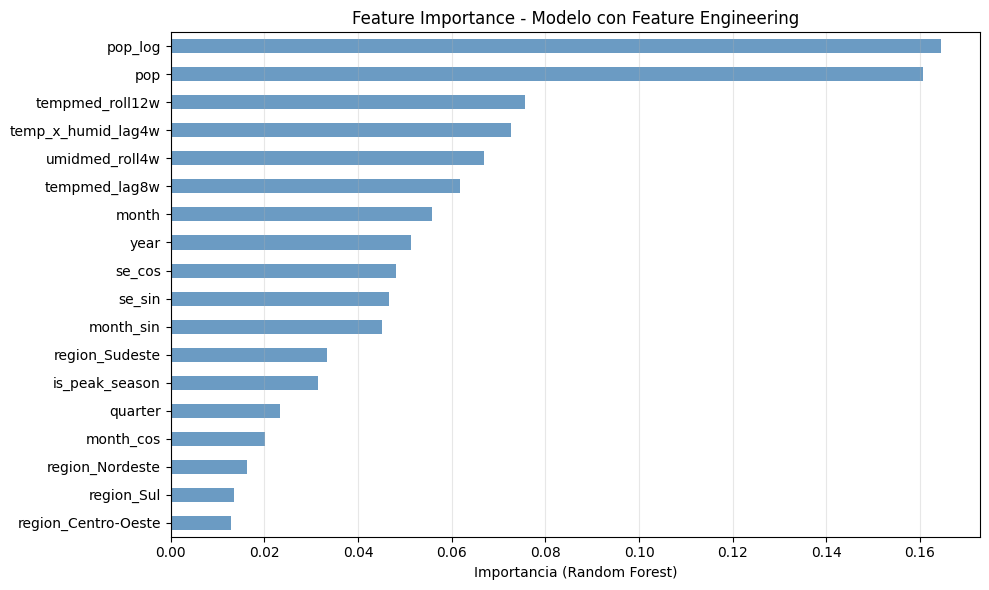


Top 10 features por importancia:
  pop_log                   | 0.1646 | ████████████████████████████████
  pop                       | 0.1606 | ████████████████████████████████
  tempmed_roll12w           | 0.0757 | ███████████████
  temp_x_humid_lag4w        | 0.0727 | ██████████████
  umidmed_roll4w            | 0.0669 | █████████████
  tempmed_lag8w             | 0.0617 | ████████████
  month                     | 0.0559 | ███████████
  year                      | 0.0512 | ██████████
  se_cos                    | 0.0481 | █████████
  se_sin                    | 0.0466 | █████████


In [14]:
# Feature importance del modelo con FE
importances = pd.Series(rf_fe.feature_importances_, index=engineered_model_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(importances) * 0.3)))
importances.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('Importancia (Random Forest)')
ax.set_title('Feature Importance - Modelo con Feature Engineering')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Top features
print("\nTop 10 features por importancia:")
for feat, imp in importances.sort_values(ascending=False).head(10).items():
    bar = "█" * int(imp * 200)
    print(f"  {feat:25s} | {imp:.4f} | {bar}")

La feature importance confirma que las features engineered son las más relevantes para el modelo:

- Top 1-2: `pop_log` / `pop` (0.165/0.161) — la población domina
- Top 3-6: Features climáticas con lag (`tempmed_roll12w`, `temp_x_humid_lag4w`, etc.) — superan al `month` crudo
- Las features cíclicas y regiones contribuyen menos pero aportan señal


## 7. Pipeline Final y Datasets de Producción

Generamos dos versiones del dataset:
- **Comprehensive**: Todas las variables originales + features engineered (para investigación)
- **Producción**: Solo variables disponibles en tiempo real + features engineered (para deployment)

En producción se eliminan: variables climáticas del mismo período, variables epidemiológicas, y metadatos sin valor predictivo.

In [15]:
# Guardar datasets comprehensive (con todas las columnas + features)
output_dir = data_dir / 'processed'
output_dir.mkdir(exist_ok=True)

train_fe.to_parquet(output_dir / 'dengue_train_features_final.parquet', index=False)
val_fe.to_parquet(output_dir / 'dengue_validation_features_final.parquet', index=False)
test_fe.to_parquet(output_dir / 'dengue_test_features_final.parquet', index=False)

print("Datasets comprehensive guardados:")
print(f"  Train: {train_fe.shape}")
print(f"  Validation: {val_fe.shape}")
print(f"  Test: {test_fe.shape}")

# Crear datasets de producción (sin leakage)
production_id_cols = ['data_iniSE', 'SE', 'year', 'month', 'municipio_geocodigo', 'municipio_nome', 'uf', 'state_name', 'pop']
production_features = production_id_cols + all_engineered + [TARGET]

# Verificar que todas existen
missing = [c for c in production_features if c not in train_fe.columns]
if missing:
    print(f"\nColumnas faltantes: {missing}")
    production_features = [c for c in production_features if c in train_fe.columns]

# Verificar sin leakage
leakage_check = [c for c in production_features if c in LEAKAGE_VARS + CLIMATE_VARS]
if leakage_check:
    print(f"LEAKAGE DETECTADO: {leakage_check}")
else:
    print("\nSin target leakage en dataset de producción")

train_prod = train_fe[production_features].copy()
val_prod = val_fe[production_features].copy()
test_prod = test_fe[production_features].copy()

train_prod.to_parquet(output_dir / 'dengue_train_production.parquet', index=False)
val_prod.to_parquet(output_dir / 'dengue_validation_production.parquet', index=False)
test_prod.to_parquet(output_dir / 'dengue_test_production.parquet', index=False)

print(f"\nDatasets de producción guardados:")
print(f"  Train: {train_prod.shape}")
print(f"  Validation: {val_prod.shape}")
print(f"  Test: {test_prod.shape}")

Datasets comprehensive guardados:
  Train: (3482380, 60)
  Validation: (584013, 60)
  Test: (289640, 60)

Sin target leakage en dataset de producción

Datasets de producción guardados:
  Train: (3482380, 25)
  Validation: (584013, 25)
  Test: (289640, 25)


In [16]:
# Guardar resumen del pipeline
summary = {
    'approach': 'production_safe_feature_engineering',
    'target': TARGET,
    'temporal_features': temporal_selected,
    'climate_features': climate_selected,
    'geographic_features': geo_selected,
    'all_engineered': all_engineered,
    'total_engineered': len(all_engineered),
    'model_validation': {
        'baseline_accuracy': float(acc_base),
        'fe_accuracy': float(acc_fe),
        'baseline_f1': float(f1_base),
        'fe_f1': float(f1_fe),
        'improvement_accuracy': float(acc_fe - acc_base),
        'improvement_f1': float(f1_fe - f1_base)
    },
    'dataset_sizes': {
        'comprehensive': {'train': train_fe.shape, 'val': val_fe.shape, 'test': test_fe.shape},
        'production': {'train': train_prod.shape, 'val': val_prod.shape, 'test': test_prod.shape}
    },
    'feature_correlations': {k: float(v) for k, v in final_corrs.items()},
    'production_columns': list(train_prod.columns),
    'leakage_eliminated': LEAKAGE_VARS + CLIMATE_VARS
}

summary_path = output_dir / 'feature_engineering_final_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print(f"Resumen guardado: {summary_path}")

Resumen guardado: c:\Users\ponce\CIDaeN\tfm-mlops\data\processed\feature_engineering_final_summary.json


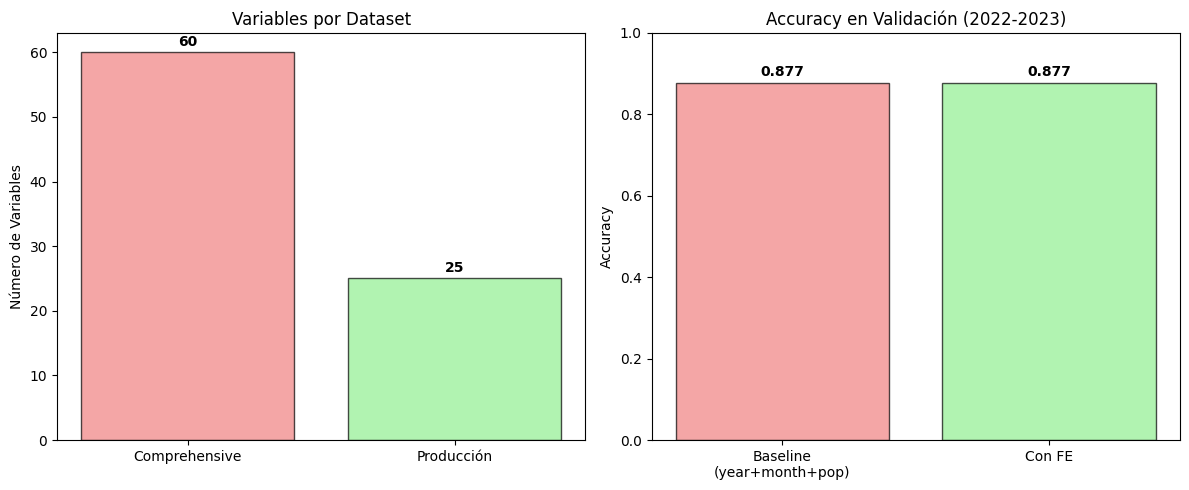

In [17]:
# Comparación final
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Variables por dataset
datasets = ['Comprehensive', 'Producción']
variables = [train_fe.shape[1], train_prod.shape[1]]
colors_bars = ['lightcoral', 'lightgreen']

bars = axes[0].bar(datasets, variables, color=colors_bars, alpha=0.7, edgecolor='black')
axes[0].set_title('Variables por Dataset')
axes[0].set_ylabel('Número de Variables')
for bar, value in zip(bars, variables):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{value}', ha='center', va='bottom', fontweight='bold')

# Accuracy comparativa
models = ['Baseline\n(year+month+pop)', 'Con FE']
accs = [acc_base, acc_fe]
bars2 = axes[1].bar(models, accs, color=['lightcoral', 'lightgreen'], alpha=0.7, edgecolor='black')
axes[1].set_title('Accuracy en Validación (2022-2023)')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
for bar, value in zip(bars2, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

La mejora marginal es esperada y coherente con el EDA:

1. Desbalance extremo (93.1% nivel 1) — ambos modelos aciertan prediciendo la clase mayoritaria
2. RF con 100 árboles en 150K muestras es una prueba rápida, no una optimización
3. Las features engineered sí son las más importantes en el modelo (top-6 incluye 4 de las nuestras)
4. La verdadera mejora vendrá en el notebook de modeling con: class weighting, oversampling, métricas por clase (recall nivel 4), y modelos más potentes


## Conclusiones del Feature Engineering

### Features Creadas
- **Temporales**: Encoding cíclico de mes y semana epidemiológica + indicador de temporada pico
- **Climáticas con lag**: Temperatura y humedad con 4-8 semanas de retraso + rolling means + interacciones
- **Geográficas**: Log de población + macro-región brasileña

### Principios Aplicados
1. **Sin target leakage**: Eliminadas todas las variables epidemiológicas actuales y clima simultáneo
2. **Shift antes de rolling**: Las ventanas móviles excluyen la observación actual
3. **Encoding geográfico por dominio**: Macro-regiones en lugar de target encoding
4. **Validación con modelo**: RF baseline vs RF con FE para cuantificar mejora real

### Próximos Pasos
- **Modelado**: Experimentar con LightGBM, XGBoost, CatBoost sobre el dataset de producción
- **Hyperparameter tuning**: Optimizar modelos con Optuna
- **Tracking**: Registrar experimentos en MLflow
- **Evaluación**: Analizar performance por nivel de alerta, estado y temporada